# 06 · The Fractal Clock, and Whether It Is Shared

Notebook 05 found the information in a **clock** — the timing of pivots. Two
questions now. Is that clock a genuine **fractal** (self-similar across scales)? And
is each instrument's clock its own, or do markets share **one common clock**?

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. The clock is a fractal point process

Think of the pivots as events on a timeline. Chop the timeline into windows of size
$T$ and count events per window. For a *memoryless* process the spread of those
counts (variance ÷ mean, the **Fano factor**) stays flat as $T$ grows. For a
**clustered, self-similar** process it grows as a power law $F(T)\sim T^{\alpha}$.
The exponent $\alpha$ measures the clustering; $\alpha=0$ is memoryless.

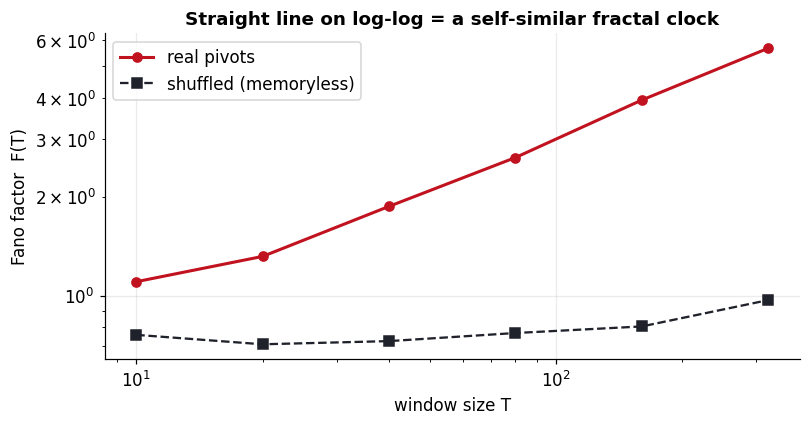

In [2]:
from controls import load_long_sequences, return_shuffle
from point_process import pivot_indices, fano_exponent
import math, random, statistics
rng = random.Random(0)

s = load_long_sequences()["SP500"]
theta = 0.02
windows = [10, 20, 40, 80, 160, 320]

def fano_curve(seq):
    idx = pivot_indices(seq, theta); N = len(seq); xs, ys = [], []
    for T in windows:
        nb = N // T
        if nb < 4: continue
        counts = [0]*nb
        for t in idx:
            if t//T < nb: counts[t//T] += 1
        m = statistics.mean(counts)
        if m > 0 and statistics.pvariance(counts) > 0:
            xs.append(T); ys.append(statistics.pvariance(counts)/m)
    return xs, ys

xr, yr = fano_curve(s)
xs_, ys_ = fano_curve(return_shuffle(s, rng))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(xr, yr, "o-", color=HL, lw=2, label="real pivots")
ax.plot(xs_, ys_, "s--", color=INK, label="shuffled (memoryless)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("window size T"); ax.set_ylabel("Fano factor  F(T)")
ax.legend(); ax.set_title("Straight line on log-log = a self-similar fractal clock")
plt.tight_layout(); plt.show()

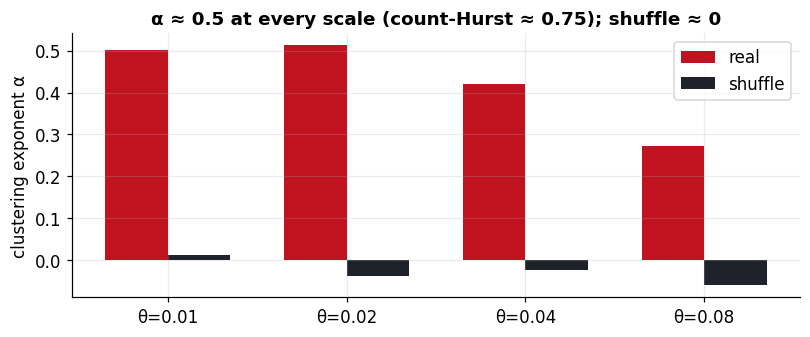

Real α stays ~0.5 across scales -> self-similar. Shuffle sits at ~0 -> memoryless.


In [3]:
# the clustering exponent alpha at several reversal scales -> approximately scale-invariant
seqs = load_long_sequences()
thetas = [0.01, 0.02, 0.04, 0.08]
alpha_real, alpha_shuf = [], []
for th in thetas:
    ar, ash = [], []
    for seq in seqs.values():
        ar.append(fano_exponent(pivot_indices(seq, th), len(seq), windows)["alpha"])
        ash.append(fano_exponent(pivot_indices(return_shuffle(seq, rng), th), len(seq), windows)["alpha"])
    alpha_real.append(statistics.mean(a for a in ar if a==a))
    alpha_shuf.append(statistics.mean(a for a in ash if a==a))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
x = np.arange(len(thetas)); w = 0.35
ax.bar(x-w/2, alpha_real, w, color=HL, label="real")
ax.bar(x+w/2, alpha_shuf, w, color=INK, label="shuffle")
ax.set_xticks(x); ax.set_xticklabels([f"θ={t}" for t in thetas]); ax.set_ylabel("clustering exponent α")
ax.legend(); ax.set_title("α ≈ 0.5 at every scale (count-Hurst ≈ 0.75); shuffle ≈ 0")
plt.tight_layout(); plt.show()
print("Real α stays ~0.5 across scales -> self-similar. Shuffle sits at ~0 -> memoryless.")

## 2. The clock is largely *shared*

Now align many instruments on the same calendar and build each one's **activity**
signal (pivots per window). If markets shared one activity clock, these signals
would move together. They do.

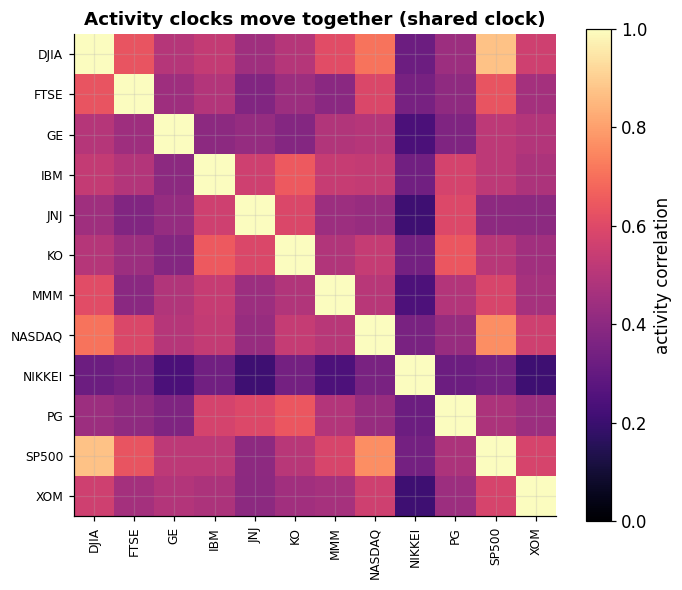

mean pairwise activity correlation: 0.478
variance of each clock explained by the common (leave-one-out) clock: mean R² = 0.446


In [4]:
from shared_clock import activity_matrix, pearson, leave_one_out_common

names, acts = activity_matrix(theta=0.02, window=30)
n = len(names)
C = np.array([[pearson(acts[i], acts[j]) for j in range(n)] for i in range(n)])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(C, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(names, fontsize=8)
plt.colorbar(im, label="activity correlation")
ax.set_title("Activity clocks move together (shared clock)")
plt.tight_layout(); plt.show()

r2 = [pearson(acts[j], leave_one_out_common(acts, j))**2 for j in range(n)]
offdiag = C[np.triu_indices(n, 1)]
print(f"mean pairwise activity correlation: {offdiag.mean():.3f}")
print(f"variance of each clock explained by the common (leave-one-out) clock: mean R² = {np.mean(r2):.3f}")

## Takeaways

* The pivot clock is a **self-similar fractal point process**: its Fano factor grows
  as a clean power law (exponent α ≈ 0.5, count-Hurst ≈ 0.75), the same at every
  reversal scale, while a shuffle is flat.
* The clock is **largely shared**: instruments' activity signals correlate strongly,
  and a common signal explains about half of each one's timing.
* *Honest limit (see the bitácora):* the shared clock is **synchronous**, not a
  lead-lag predictor — it does not let one instrument forecast another's future.

**Next (07):** we recurse once more — the *clock of the clock* — and study the shape
of a single leg.